In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
files.upload()

Saving shein-products.csv to shein-products.csv


{'shein-products.csv': b'product_name,description,initial_price,final_price,currency,in_stock,color,size,reviews_count,main_image,category_url,url,category_tree,country_code,domain,image_count,image_urls,model_number,offers,other_attributes,product_id,rating,related_products,root_category,top_reviews,category,brand,all_available_sizes\n"Tall Narrow Bathroom Storage Cabinet With 3 Drawers And 2 Shelves, Free Standing Kitchen Pantry Organizer With Open Compartment, Water-Resistant Finish","Free Returns \xe2\x9c\x93 Free Shipping\xe2\x9c\x93. Tall Narrow Bathroom Storage Cabinet With 3 Drawers And 2 Shelves, Free Standing Kitchen Pantry Organizer With Open Compartment, Water-Resistant Finish- Storage Cabinets at SHEIN.",120.99,120.99,"USD",true,"Grey","one-size",0,"https://img.ltwebstatic.com/images3_spmp/2024/08/09/e4/17231883609d35f827fa9cc1016466bcd0d72748bd_square.png","https://us.shein.com/Storage-Cabinets-c-4929.html","https://us.shein.com/Tall-Narrow-Bathroom-Storage-Cabinet-With-3

In [ ]:
df = pd.read_csv("shein-products.csv")


In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1000 non-null   object 
 1   description          1000 non-null   object 
 2   initial_price        1000 non-null   float64
 3   final_price          1000 non-null   float64
 4   currency             1000 non-null   object 
 5   in_stock             1000 non-null   bool   
 6   color                937 non-null    object 
 7   size                 1000 non-null   object 
 8   reviews_count        1000 non-null   int64  
 9   main_image           1000 non-null   object 
 10  category_url         1000 non-null   object 
 11  url                  1000 non-null   object 
 12  category_tree        1000 non-null   object 
 13  country_code         1000 non-null   object 
 14  domain               1000 non-null   object 
 15  image_count          1000 non-null   in

In [ ]:
df['discount'] = (df['initial_price'] - df['final_price']) / df['initial_price']

In [ ]:
df['discount_percent'] = df['discount'] * 100

In [ ]:
df[['initial_price', 'final_price', 'discount_percent']].head()

,initial_price,final_price,discount_percent
0,120.99,120.99,0.000000
1,2.10,2.10,0.000000
2,3.39,2.14,36.873156
3,22.80,21.30,6.578947
4,28.53,28.53,0.000000


In [ ]:
df[df['final_price'] > df['initial_price']]

,product_name,description,initial_price,final_price,currency,in_stock,color,size,reviews_count,main_image,...,product_id,rating,related_products,root_category,top_reviews,category,brand,all_available_sizes,discount,discount_percent


In [ ]:
df = df[df['initial_price'] > 0]  # remove zero prices
df = df.dropna(subset=['discount'])  # remove nulls

In [ ]:
# Stage 1: All products (just count later)

# Stage 2: Discounted
df['is_discounted'] = df['discount'] > 0

# Stage 3: High discount (≥30%)
df['is_high_discount'] = df['discount'] >= 0.30

# Stage 4: In stock
df['is_in_stock'] = df['in_stock'].astype(str).str.lower() == 'yes'

In [ ]:
df['in_stock'].unique()

array([ True])

In [ ]:
total_products = len(df)
discounted = df['is_discounted'].sum()
high_discount = df['is_high_discount'].sum()
in_stock = df['is_in_stock'].sum()

print(total_products, discounted, high_discount, in_stock)

1000 609 108 0


In [ ]:
stage1 = df

stage2 = stage1[stage1['discount'] > 0]

stage3 = stage2[stage2['discount'] >= 0.30]

stage4 = stage3[stage3['is_in_stock']]

In [ ]:
funnel = pd.DataFrame({
    'Stage': ['All Products', 'Discounted', 'High Discount', 'In Stock'],
    'Count': [len(stage1), len(stage2), len(stage3), len(stage4)]
})

print(funnel)

           Stage  Count
0   All Products   1000
1     Discounted    609
2  High Discount    108
3       In Stock      0


In [ ]:
df['in_stock'].unique()

array([ True])

In [ ]:
df['is_in_stock'] = df['in_stock']

In [ ]:
df['is_in_stock'] = df['in_stock'] == True

In [ ]:
df['is_in_stock'] = df['in_stock'] == 1

In [ ]:
stage4 = stage3[stage3['is_in_stock']]

In [ ]:
df['in_stock'].unique()

array([ True])

In [ ]:
funnel = pd.DataFrame({
    'Stage': ['All Products', 'Discounted', 'High Discount', 'In Stock'],
    'Count': [
        df.shape[0],
        df[df['final_price'] < df['initial_price']].shape[0],
        df[df['final_price'] < 0.5 * df['initial_price']].shape[0],
        df[df['in_stock'] == 'Yes'].shape[0]
    ]
})
print(funnel)

           Stage  Count
0   All Products   1000
1     Discounted    609
2  High Discount     13
3       In Stock      0


In [ ]:
print(df['in_stock'].unique())

[ True]


In [ ]:
df[df['in_stock'] == 'Yes']

,product_name,description,initial_price,final_price,currency,in_stock,color,size,reviews_count,main_image,...,root_category,top_reviews,category,brand,all_available_sizes,discount,discount_percent,is_discounted,is_high_discount,is_in_stock


In [ ]:
df[df['in_stock']]

,product_name,description,initial_price,final_price,currency,in_stock,color,size,reviews_count,main_image,...,root_category,top_reviews,category,brand,all_available_sizes,discount,discount_percent,is_discounted,is_high_discount,is_in_stock
0,Tall Narrow Bathroom Storage Cabinet With 3 Dr...,Free Returns ✓ Free Shipping✓. Tall Narrow Bat...,120.99,120.99,USD,True,Grey,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Tools & Home Improvement,NaN,Storage Cabinets,SHEIN,"[""one-size""]",0.000000,0.000000,False,False,True
1,"1PC Natural Yellow Rainbow Halo Raw Crystal, A...",Free Returns ✓ Free Shipping✓. 1PC Natural Yel...,2.10,2.10,USD,True,Multicolor,Electroplated Citrine,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Jewelry & Watches,NaN,Crystal Shapes & Carvings,SHEIN,"[""Electroplated Citrine""]",0.000000,0.000000,False,False,True
2,1PC Sexy Lingerie Body StockingOpen Crotch Hol...,Free Returns ✓ Free Shipping✓. 1PC Sexy Linger...,3.39,2.14,USD,True,Black,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Underwear & Sleepwear,NaN,Women Sexy Bodysuits,SHEIN,"[""one-size""]",0.368732,36.873156,True,True,True
3,"Italian Genuine Leather Thick Belt For Men, Re...",Free Returns ✓ Free Shipping✓. Italian Genuine...,22.80,21.30,USD,True,Black,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Men,NaN,Men Belts,SHEIN,"[""one-size""]",0.065789,6.578947,True,False,True
4,Unbeatablesale Hylomar 61701 13.53 Oz Hylomar ...,Free Returns ✓ Free Shipping✓. Unbeatablesale ...,28.53,28.53,USD,True,Multicolor,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Home & Living,NaN,Other Commercial Cleaning Supplies,Unbeatablesale,"[""one-size""]",0.000000,0.000000,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1pc Uv Protection Rain/Sun Dual-Use Mini Umbre...,Free Returns ✓ Free Shipping✓. 1pc Uv Protecti...,7.40,7.20,USD,True,Black,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Home & Living,NaN,Umbrellas and Rain Hat Umbrellas,SHEIN,"[""one-size""]",0.027027,2.702703,True,False,True
996,"Electronics Organizer Travel Case, Carrying Po...",Free Returns ✓ Free Shipping✓. Electronics Org...,6.60,6.20,USD,True,Grey,one-size,0,https://img.ltwebstatic.com/images3_spmp/2023/...,...,Bags & Luggage,NaN,Digital Bags,SHEIN,"[""one-size""]",0.060606,6.060606,True,False,True
997,30g/Pack Plastic Macaroon Color Chili Shaped H...,Free Returns ✓ Free Shipping✓. 30g/Pack Plasti...,1.60,1.60,USD,True,Multicolor,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Jewelry & Watches,NaN,Beads,SHEIN,"[""one-size""]",0.000000,0.000000,False,False,True
998,Jepeak Jepeak Pack Of 4 20x20 Inch Throw Pillo...,Free Returns ✓ Free Shipping✓. Jepeak Jepeak P...,33.60,24.20,USD,True,Light Grey,50*50,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Home Textile,NaN,Cushion Cover,Jepeak,"[""50*50""]",0.279762,27.976190,True,False,True


In [ ]:
df[df['final_price'] <= 0.7 * df['initial_price']]  # 30%+ discount

,product_name,description,initial_price,final_price,currency,in_stock,color,size,reviews_count,main_image,...,root_category,top_reviews,category,brand,all_available_sizes,discount,discount_percent,is_discounted,is_high_discount,is_in_stock
2,1PC Sexy Lingerie Body StockingOpen Crotch Hol...,Free Returns ✓ Free Shipping✓. 1PC Sexy Linger...,3.39,2.14,USD,True,Black,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Underwear & Sleepwear,NaN,Women Sexy Bodysuits,SHEIN,"[""one-size""]",0.368732,36.873156,True,True,True
8,20pcs Artificial Green Plant Leaves Valentine'...,Free Returns ✓ Free Shipping✓. 20pcs Artificia...,1.50,0.83,USD,True,Multicolor,one-size,0,https://img.ltwebstatic.com/images3_pi/2023/03...,...,Home & Living,NaN,Artificial Plants,SHEIN,"[""one-size""]",0.446667,44.666667,True,True,True
12,Juvale Wooden Drawer Organizer With 12 Compart...,Free Returns ✓ Free Shipping✓. Juvale Wooden D...,25.70,17.99,USD,True,Brown,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Home & Living,NaN,Storage Drawers,SHEIN,"[""one-size""]",0.300000,30.000000,True,True,True
16,Dolce & Gabbana 1.6oz The Only One For Women -...,Free Returns ✓ Free Shipping✓. Dolce & Gabbana...,98.00,66.74,USD,True,Default,1.6oz,0,https://img.ltwebstatic.com/images3_spmp/2023/...,...,Beauty & Health,NaN,Perfume,Dolce & Gabbana,"[""1.6oz""]",0.318980,31.897959,True,True,True
37,144 Pieces Pizza Party Supplies Pack Decoratio...,Free Returns ✓ Free Shipping✓. 144 Pieces Pizz...,38.99,23.49,USD,True,Black,one-size,0,https://img.ltwebstatic.com/images3_spmp/2023/...,...,Home & Living,NaN,Disposable Tableware Sets,SHEIN,"[""one-size""]",0.397538,39.753783,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,Table,Free Returns ✓ Free Shipping✓. Table- Home Off...,699.99,299.99,USD,True,Pink,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Tools & Home Improvement,NaN,Home Office Desks,SHEIN,"[""one-size""]",0.571437,57.143673,True,True,True
962,"IAGREEA Electric Mixer, Electric Mini Garlic M...",Free Returns ✓ Free Shipping✓. IAGREEA Electri...,17.29,8.10,USD,True,Pink,large size/250ml,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Home Appliances,NaN,Hand Blenders,SHEIN,"[""large size/250ml""]",0.531521,53.152111,True,True,True
973,1pc Trendy Angel Wings & Heart Rhinestone Deco...,Free Returns ✓ Free Shipping✓. 1pc Trendy Ange...,2.70,0.81,USD,True,Multicolor,one-size,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Jewelry & Watches,NaN,Women Chain Bracelets,SHEIN,"[""one-size""]",0.700000,70.000000,True,True,True
980,Women's Kitten Heel Booties Pointed Toe Low St...,Free Returns ✓ Free Shipping✓. Women's Kitten ...,49.90,26.61,USD,True,black2,US7.5,0,https://img.ltwebstatic.com/images3_spmp/2024/...,...,Shoes,NaN,Women Ankle Boots & Booties,SHEIN,"[""US7.5""]",0.466733,46.673347,True,True,True


In [ ]:
funnel = pd.DataFrame({
    'Stage': ['All Products', 'Discounted', 'High Discount', 'In Stock'],
    'Count': [
        df.shape[0],
        df[df['final_price'] < df['initial_price']].shape[0],
        df[df['final_price'] <= 0.7 * df['initial_price']].shape[0],  # adjust threshold
        df[df['in_stock']].shape[0]  # Corrected to use boolean column directly
    ]
})
print(funnel)

           Stage  Count
0   All Products   1000
1     Discounted    609
2  High Discount    107
3       In Stock   1000


In [ ]:
# Stage 1: All Products
all_products = df

# Stage 2: Discounted
discounted = all_products[all_products['final_price'] < all_products['initial_price']]

# Stage 3: High Discount
high_discount = discounted[discounted['final_price'] <= 0.7 * discounted['initial_price']]  # 30%+ discount

# Stage 4: In Stock
in_stock = high_discount[high_discount['in_stock']]  # Corrected to use boolean column directly

# Build funnel
funnel = pd.DataFrame({
    'Stage': ['All Products', 'Discounted', 'High Discount', 'In Stock'],
    'Count': [
        all_products.shape[0],
        discounted.shape[0],
        high_discount.shape[0],
        in_stock.shape[0]
    ]
})

print(funnel)

           Stage  Count
0   All Products   1000
1     Discounted    609
2  High Discount    107
3       In Stock    107


In [ ]:
funnel['Conversion %'] = funnel['Count'] / funnel['Count'].iloc[0] * 100
print(funnel)

           Stage  Count  Conversion %
0   All Products   1000         100.0
1     Discounted    609          60.9
2  High Discount    107          10.7
3       In Stock    107          10.7


In [ ]:
import plotly.graph_objects as go

# Funnel data
stages = ['All Products', 'Discounted', 'High Discount', 'In Stock']
counts = [1000, 609, 107, 107]

fig = go.Figure(go.Funnel(
    y=stages,
    x=counts,
    textinfo="value+percent initial"  # shows count + % of first stage
))

fig.update_layout(title="SHEIN Pricing Funnel Analysis")
fig.show()

In [ ]:
print(df['category'].unique())

['Storage Cabinets' 'Crystal Shapes & Carvings' 'Women Sexy Bodysuits'
 'Men Belts' 'Other Commercial Cleaning Supplies' 'Teacup & Saucer Sets'
 'Tool Cases' 'Decorative Balloons' 'Artificial Plants'
 'Wrapping & Packaging' 'Decorative Crafts' 'Rhinestones & Decorations'
 'Storage Drawers' 'Sockets' 'Travel Glasses Bag' 'Women Tongue Ring'
 'Perfume' 'Car Replacement Parts' 'Men Tote Bags' 'Cushion Cover'
 'Notebooks' 'Colored Pencils' 'Fine Pendant Necklaces'
 'Jewelry Making Findings' 'Other Tool Organizers' 'Handwear'
 'Party Games & Activities' 'Wall Decoration' 'Jewelry Boxes'
 'Artificial Flowers' 'Other Sports Accessories' 'Coat Racks'
 'Table Decorative Ornaments' 'Cycling Mask & Scarf'
 'Disposable Tableware Sets' 'Horse Grooming & Bathing Supplies'
 'Hair Bands' 'Synthetic Extensions' 'Other Party Supplies'
 'Watering Kits' 'Mops and Mop Sets' 'Party Backdrops'
 'Disposable Napkins' 'Hair Clips' 'Press On False Nails'
 'Mirror Stickers' 'Swimming Pools' 'Women Top Handle Bags

In [ ]:
categories = df['category'].unique()

category_funnel = []

for cat in categories:
    data = df[df['category'] == cat]

    discounted = data[data['final_price'] < data['initial_price']]
    high_discount = discounted[discounted['final_price'] <= 0.7 * discounted['initial_price']]
    in_stock = high_discount[high_discount['in_stock']]

    category_funnel.append({
        'Category': cat,
        'All Products': data.shape[0],
        'Discounted': discounted.shape[0],
        'High Discount': high_discount.shape[0],
        'In Stock': in_stock.shape[0]
    })

import pandas as pd
category_funnel_df = pd.DataFrame(category_funnel)

print(category_funnel_df)

                               Category  All Products  Discounted  \
0                      Storage Cabinets             1           0   
1             Crystal Shapes & Carvings             2           1   
2                  Women Sexy Bodysuits             1           1   
3                             Men Belts             2           2   
4    Other Commercial Cleaning Supplies             2           1   
..                                  ...           ...         ...   
497                 Repair Tools & Kits             1           0   
498                 Other Hooks & Rails             1           1   
499                      Cocktail Picks             1           1   
500                   Duvet Covers Sets             1           1   
501                     Racks & Holders             1           1   

     High Discount  In Stock  
0                0         0  
1                1         1  
2                1         1  
3                0         0  
4               

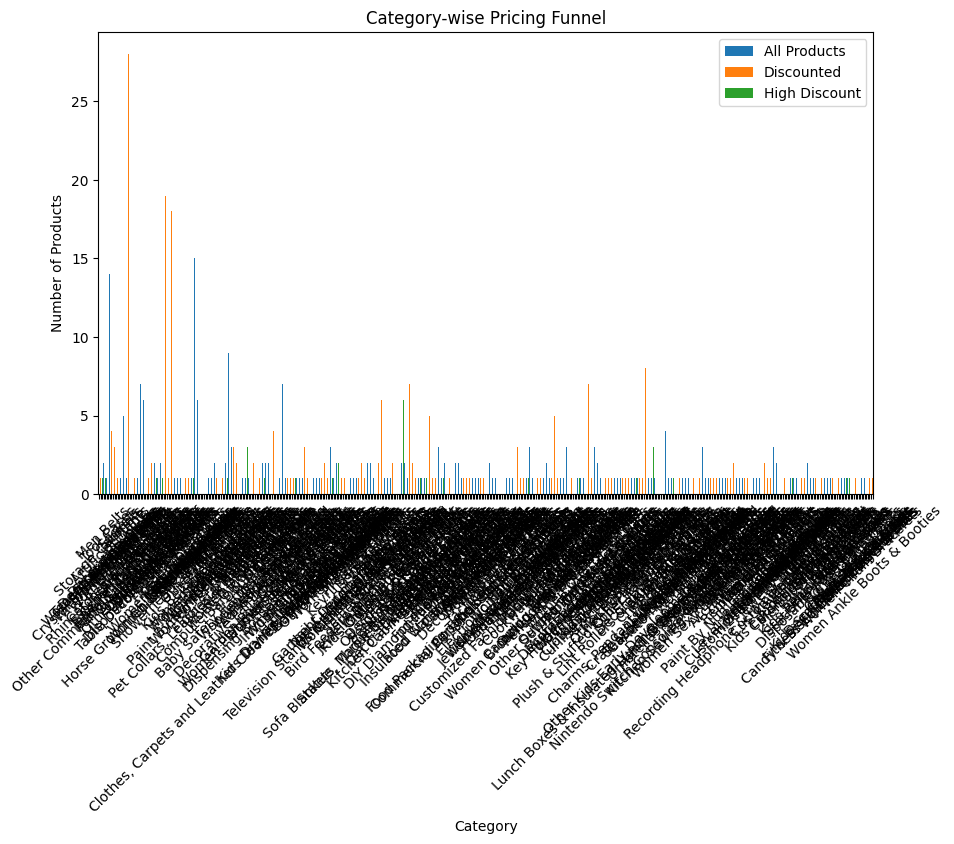

In [ ]:
import matplotlib.pyplot as plt

category_funnel_df.set_index('Category')[['All Products', 'Discounted', 'High Discount']].plot(kind='bar', figsize=(10,6))
plt.title("Category-wise Pricing Funnel")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

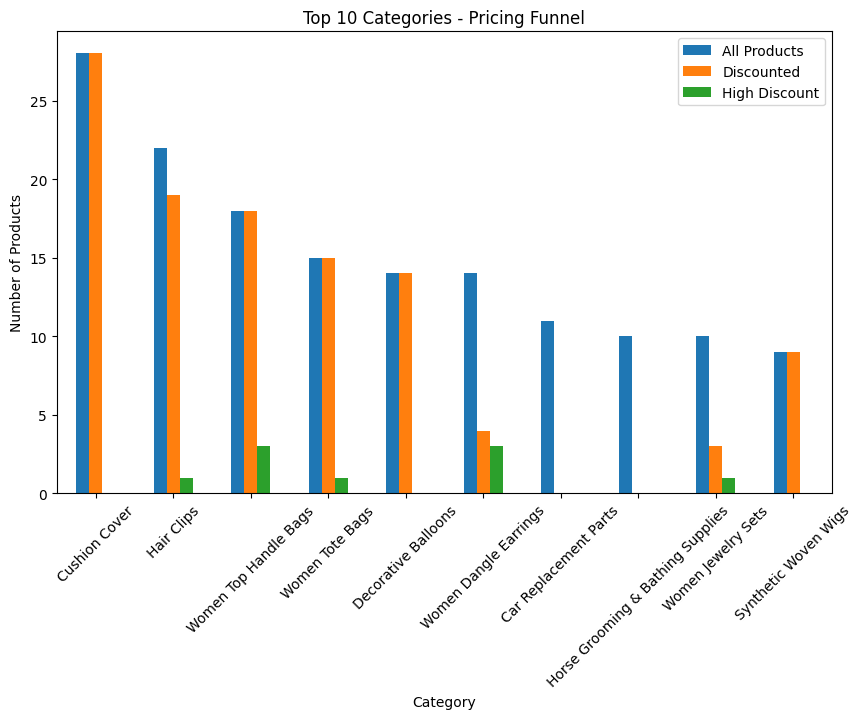

In [ ]:
# Get top 10 categories
top_categories = category_funnel_df.sort_values(by='All Products', ascending=False).head(10)

# Plot
top_categories.set_index('Category')[['All Products', 'Discounted', 'High Discount']].plot(kind='bar', figsize=(10,6))

import matplotlib.pyplot as plt
plt.title("Top 10 Categories - Pricing Funnel")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

In [ ]:
colors = df['color'].unique()

color_funnel = []

for col in colors:
    data = df[df['color'] == col]

    discounted = data[data['final_price'] < data['initial_price']]
    high_discount = discounted[discounted['final_price'] <= 0.7 * discounted['initial_price']]

    color_funnel.append({
        'Color': col,
        'Total': data.shape[0],
        'High Discount': high_discount.shape[0]
    })

color_funnel_df = pd.DataFrame(color_funnel)
print(color_funnel_df)

                     Color  Total  High Discount
0                     Grey     13              2
1               Multicolor    368             26
2                    Black     92             19
3                    White     61              5
4          Retro Telephone      1              0
..                     ...    ...            ...
130            Mocha Brown      1              0
131          Black-58*58cm      1              0
132                 black2      1              1
133             White Grey      1              0
134  22. Enchantment Coral      1              1

[135 rows x 3 columns]


In [ ]:
in_stock_df = df[df['in_stock']]
out_stock_df = df[~df['in_stock']]

print("Avg discount (In Stock):", ((in_stock_df['initial_price'] - in_stock_df['final_price']) / in_stock_df['initial_price']).mean())

print("Avg discount (Out of Stock):", ((out_stock_df['initial_price'] - out_stock_df['final_price']) / out_stock_df['initial_price']).mean())

Avg discount (In Stock): 0.11015922021798516
Avg discount (Out of Stock): nan


In [ ]:
print(df.columns)

Index(['product_name', 'description', 'initial_price', 'final_price',
       'currency', 'in_stock', 'color', 'size', 'reviews_count', 'main_image',
       'category_url', 'url', 'category_tree', 'country_code', 'domain',
       'image_count', 'image_urls', 'model_number', 'offers',
       'other_attributes', 'product_id', 'rating', 'related_products',
       'root_category', 'top_reviews', 'category', 'brand',
       'all_available_sizes', 'discount', 'discount_percent', 'is_discounted',
       'is_high_discount', 'is_in_stock'],
      dtype='object')


In [ ]:
df['discount_pct'] = (df['initial_price'] - df['final_price']) / df['initial_price']


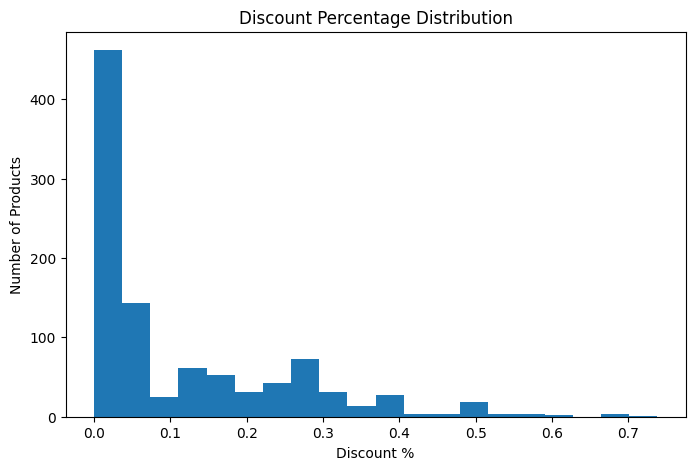

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['discount_pct'], bins=20)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.ylabel("Number of Products")

plt.show()

In [ ]:
df['discount_pct'] = (df['initial_price'] - df['final_price']) / df['initial_price']

df['is_discounted'] = df['final_price'] < df['initial_price']
df['is_high_discount'] = df['final_price'] <= 0.7 * df['initial_price']
df['is_in_stock'] = df['in_stock']

In [ ]:
df.to_csv("shein_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("shein_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>